# generate confusion matrices and per-category heatmaps


In [1]:
#install dependencies
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\brand\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path


def find_results_dir(start=None):
    here = Path(start or Path.cwd()).resolve()
    for folder in [here, *here.parents]:
        candidate = folder / 'results'
        if candidate.is_dir() and any(candidate.glob('*/per_ticket_results.csv')):
            return candidate
    raise FileNotFoundError('Could not find results/<model>/per_ticket_results.csv above ' + str(here))


RESULTS_DIR = find_results_dir()
print('Reading from', RESULTS_DIR)

Reading from C:\Users\brand\ICT3113-A1-Team8\results


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

def model_dir(model):
    """results/<model>/ - the same folder accuracy_test.js wrote that model's results into."""
    return RESULTS_DIR / model.replace(':', '_')


CATEGORIES = ['Credit reporting', 'Debt collection', 'Mortgage', 'Credit card',
              'Bank account or service', 'Consumer loan', 'Money transfer or service']
SHORT = ['Credit rep.', 'Debt coll.', 'Mortgage', 'Credit card', 'Bank acct', 'Cons. loan', 'Money tr.']
UNMATCHED = '(unmatched)'
MODEL_ORDER = ['gemma3:1b', 'gemma3:4b', 'qwen2.5:3b', 'qwen2.5:7b', 'granite3.3:8b']
FOLDER_TO_TAG = {m.replace(':', '_'): m for m in MODEL_ORDER}   # folders use _ instead of :


def rhu(x, nd=1):
    """Round half up (56.25 -> 56.3), so numbers match the summary.md files; Python's own round() gives 56.2."""
    scale = 10 ** nd
    return np.floor(np.asarray(x, dtype=float) * scale + 0.5 + 1e-9) / scale


def load_runs(results_dir):
    """Reads results/<model>/per_ticket_results.csv for every model folder."""
    runs = {}
    for path in Path(results_dir).glob('*/per_ticket_results.csv'):
        tag = FOLDER_TO_TAG.get(path.parent.name, path.parent.name)
        runs[tag] = pd.read_csv(path, keep_default_na=False)   # keep empty replies as ''
    ordered = {m: runs[m] for m in MODEL_ORDER if m in runs}
    ordered.update({m: d for m, d in runs.items() if m not in ordered})
    return ordered


def confusion(df):
    """Rows = actual (golden label), columns = predicted. Replies outside the 7 categories
    (e.g. failed requests) go in the '(unmatched)' column."""
    predicted = df['predicted_label'].where(df['predicted_label'].isin(CATEGORIES), UNMATCHED)
    cm = pd.crosstab(df['final_label'], predicted)
    return cm.reindex(index=CATEGORIES, columns=CATEGORIES + [UNMATCHED], fill_value=0)


def summarise(cm):
    vals = cm.values
    diag = np.array([cm.loc[c, c] for c in CATEGORIES])
    actual = vals.sum(axis=1)
    predicted = vals.sum(axis=0)[:len(CATEGORIES)]
    table = pd.DataFrame({
        'tickets': actual,
        'predicted': predicted,
        'recall_%': rhu(100 * diag / np.maximum(actual, 1)),
        'precision_%': rhu(np.where(predicted > 0, 100 * diag / np.maximum(predicted, 1), np.nan)),
    }, index=CATEGORIES)
    return table, diag.sum() / vals.sum()


def draw(ax, cm, title, percent=False):
    show_unmatched = cm[UNMATCHED].sum() > 0
    cols = CATEGORIES + ([UNMATCHED] if show_unmatched else [])
    vals = cm[cols].values
    rows = vals.sum(axis=1, keepdims=True)
    frac = np.divide(vals, rows, out=np.zeros(vals.shape), where=rows > 0)   # shading = share of the row
    ax.imshow(frac, cmap='Blues', vmin=0, vmax=1)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if vals[i, j] == 0:
                ax.text(j, i, '·', ha='center', va='center', color='#aaaaaa', fontsize=9)
                continue
            label = f'{rhu(100 * frac[i, j], 0):.0f}%' if percent else str(vals[i, j])
            ax.text(j, i, label, ha='center', va='center', fontsize=9,
                    color='white' if frac[i, j] > 0.55 else 'black')
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(SHORT + (['unmatched'] if show_unmatched else []), rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_yticklabels([f'{c} ({n})' for c, n in zip(CATEGORIES, rows.flatten().astype(int))], fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=11)

Models found: ['gemma3:1b', 'gemma3:4b', 'qwen2.5:3b', 'qwen2.5:7b', 'granite3.3:8b']

gemma3:1b: 23.9% accuracy (43/180)


,tickets,predicted,recall_%,precision_%
Credit reporting,53,6,11.3,100.0
Debt collection,16,39,50.0,20.5
Mortgage,26,16,38.5,62.5
Credit card,20,1,5.0,100.0
Bank account or service,23,2,4.3,50.0
Consumer loan,19,95,57.9,11.6
Money transfer or service,23,21,26.1,28.6


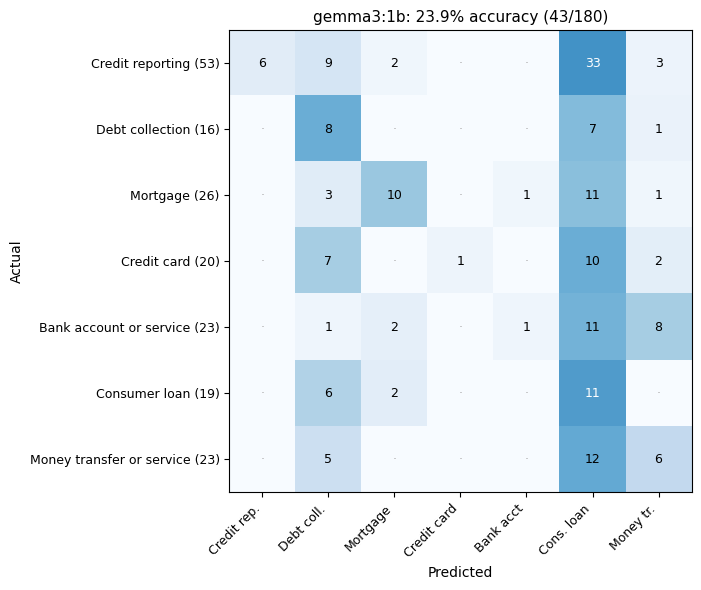


gemma3:4b: 70.6% accuracy (127/180)


,tickets,predicted,recall_%,precision_%
Credit reporting,53,52,86.8,88.5
Debt collection,16,14,56.3,64.3
Mortgage,26,30,92.3,80.0
Credit card,20,35,80.0,45.7
Bank account or service,23,20,47.8,55.0
Consumer loan,19,9,26.3,55.6
Money transfer or service,23,20,69.6,80.0


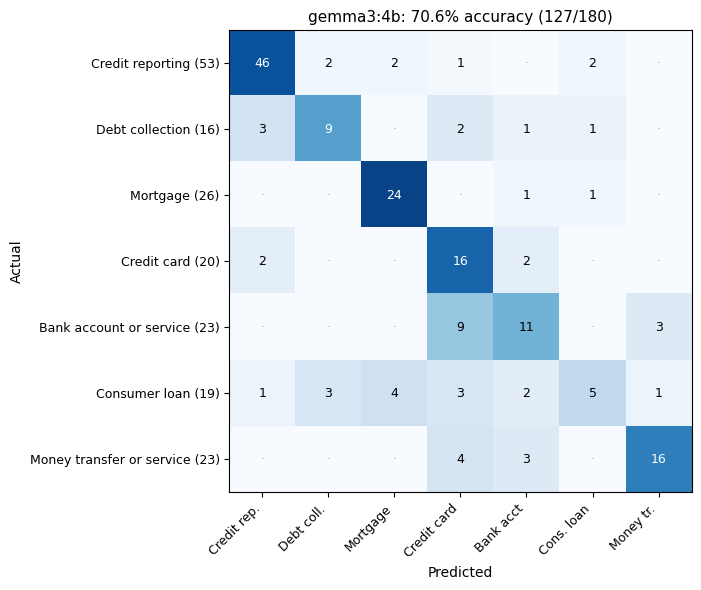


qwen2.5:3b: 61.1% accuracy (110/180)


,tickets,predicted,recall_%,precision_%
Credit reporting,53,46,79.2,91.3
Debt collection,16,11,62.5,90.9
Mortgage,26,35,92.3,68.6
Credit card,20,55,85.0,30.9
Bank account or service,23,17,34.8,47.1
Consumer loan,19,7,10.5,28.6
Money transfer or service,23,9,30.4,77.8


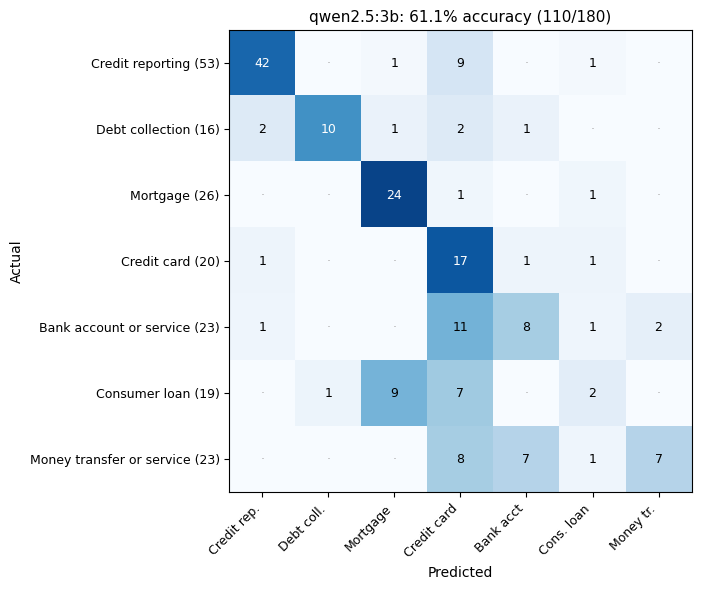


qwen2.5:7b: 75.0% accuracy (135/180)


,tickets,predicted,recall_%,precision_%
Credit reporting,53,59,90.6,81.4
Debt collection,16,25,81.3,52.0
Mortgage,26,23,84.6,95.7
Credit card,20,20,75.0,75.0
Bank account or service,23,23,65.2,65.2
Consumer loan,19,7,26.3,71.4
Money transfer or service,23,23,73.9,73.9


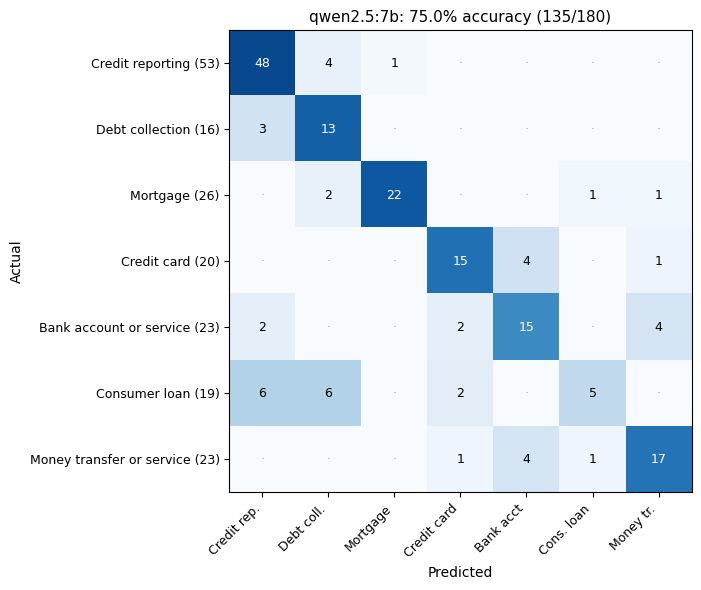


granite3.3:8b: 67.2% accuracy (121/180)


,tickets,predicted,recall_%,precision_%
Credit reporting,53,43,77.4,95.3
Debt collection,16,18,68.8,61.1
Mortgage,26,22,80.8,95.5
Credit card,20,50,100.0,40.0
Bank account or service,23,23,47.8,47.8
Consumer loan,19,15,52.6,66.7
Money transfer or service,23,9,30.4,77.8


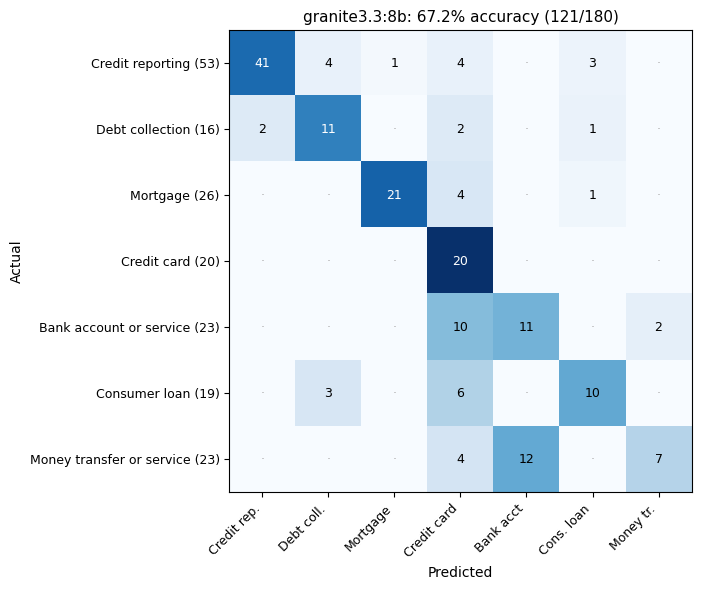

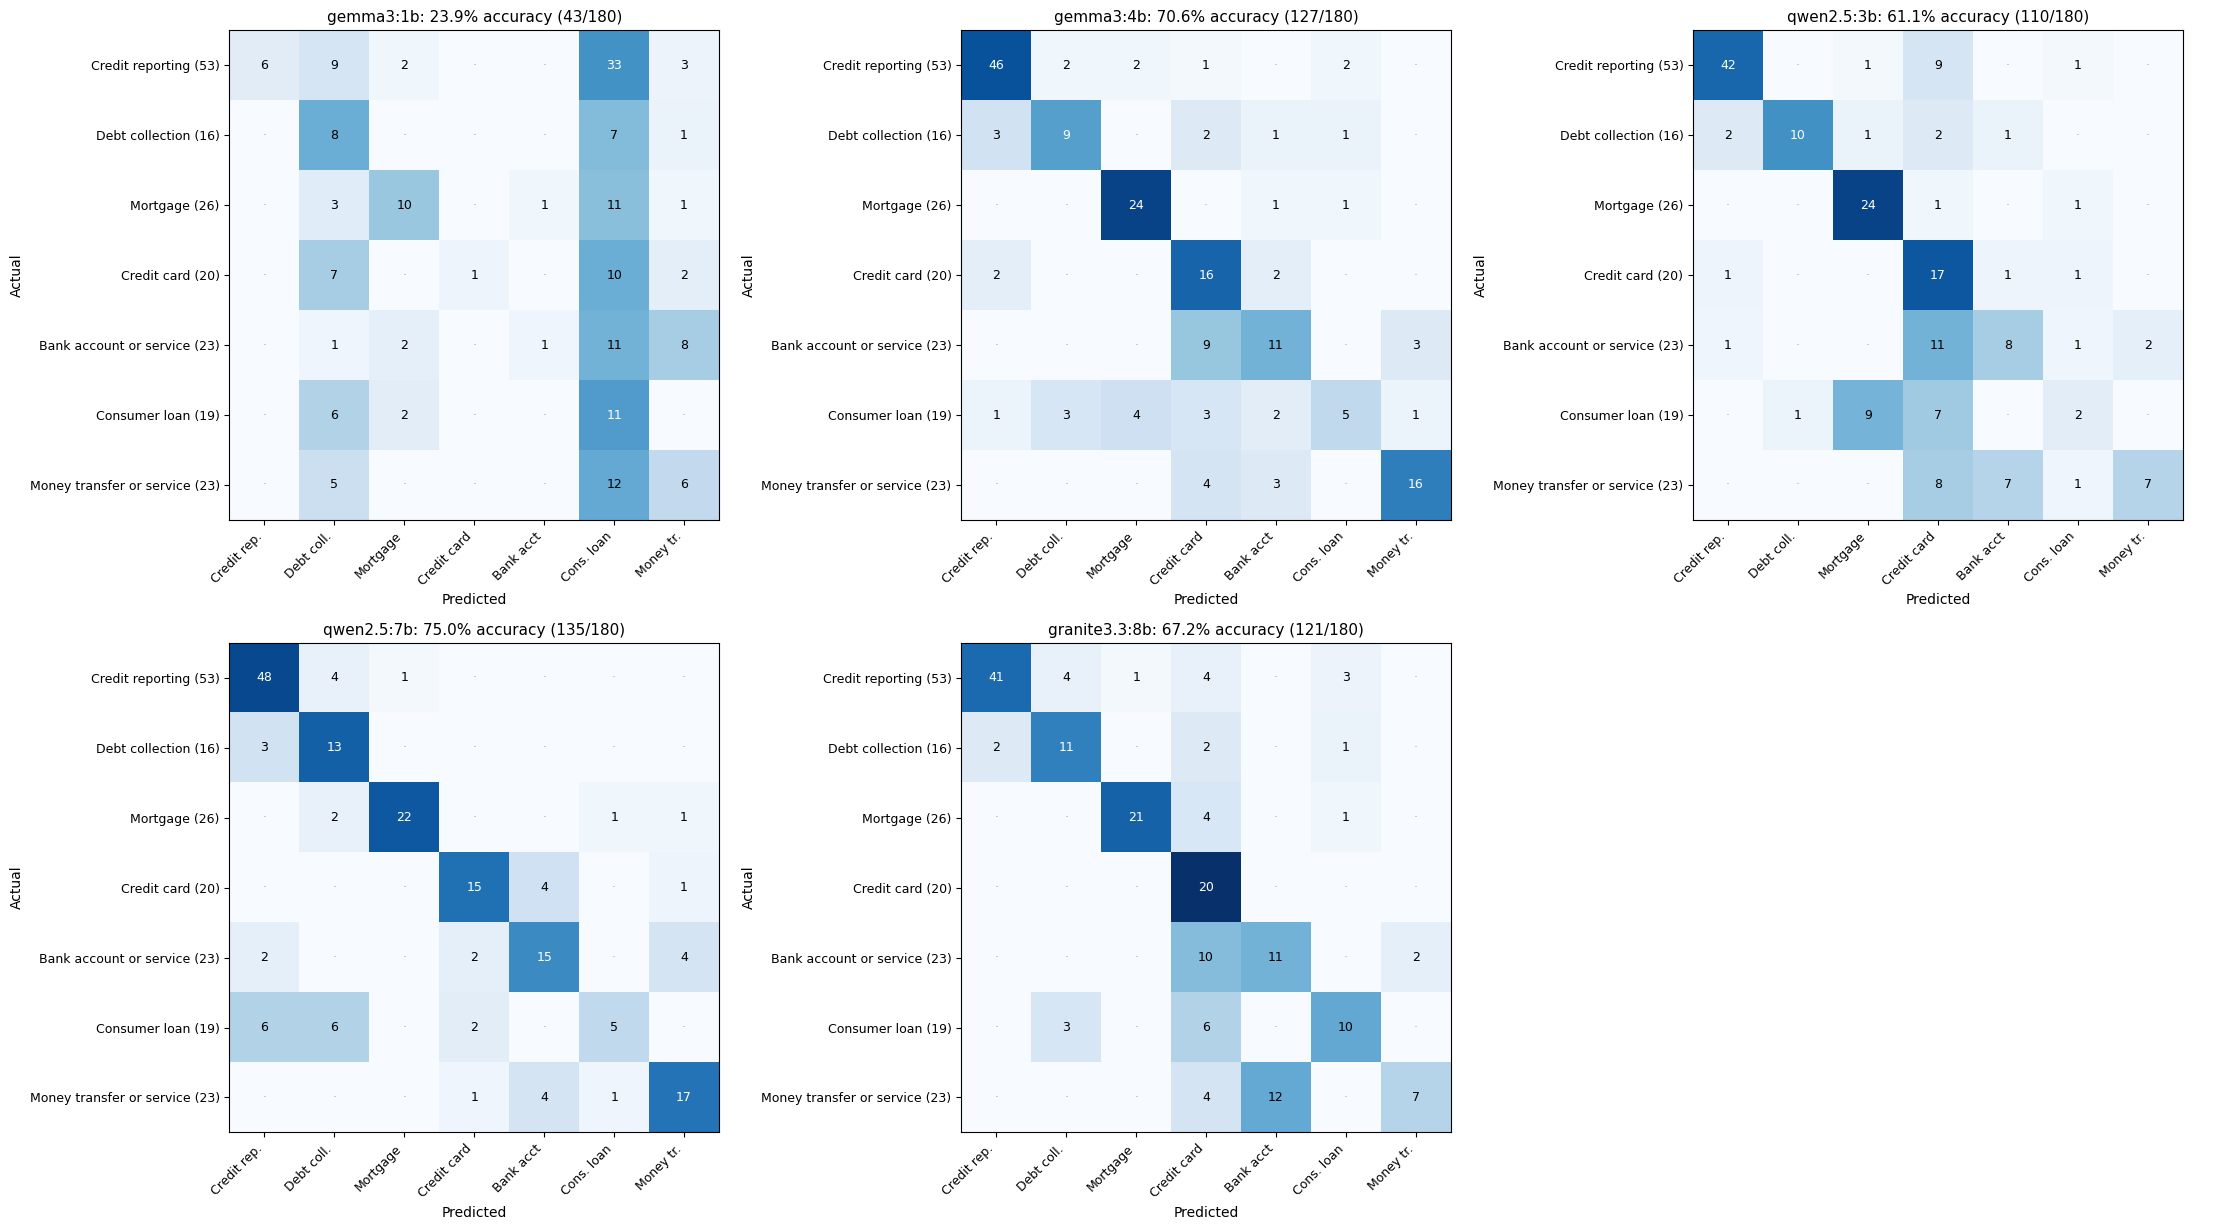

In [4]:
PERCENT = False

runs = load_runs(RESULTS_DIR)
print('Models found:', list(runs))

cms, titles = {}, {}
for model, df in runs.items():
    cm = confusion(df)
    table, acc = summarise(cm)
    correct = int(sum(cm.loc[c, c] for c in CATEGORIES))
    cms[model] = cm
    titles[model] = f'{model}: {100 * acc:.1f}% accuracy ({correct}/{len(df)})'

    print(f'\n{titles[model]}')
    display(table)

    fig, ax = plt.subplots(figsize=(7.5, 6))
    draw(ax, cm, titles[model], PERCENT)
    fig.tight_layout()
    fig.savefig(model_dir(model) / 'confusion_matrix.png', dpi=200)
    plt.show()

n = len(cms)
cols_n = 3
rows_n = int(np.ceil(n / cols_n))
fig, axes = plt.subplots(rows_n, cols_n, figsize=(7.5 * cols_n, 6.2 * rows_n))
axes = np.atleast_1d(axes).flatten()
for ax, (model, cm) in zip(axes, cms.items()):
    draw(ax, cm, titles[model], PERCENT)
for ax in axes[n:]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrices_all_models.png', dpi=200)
plt.show()

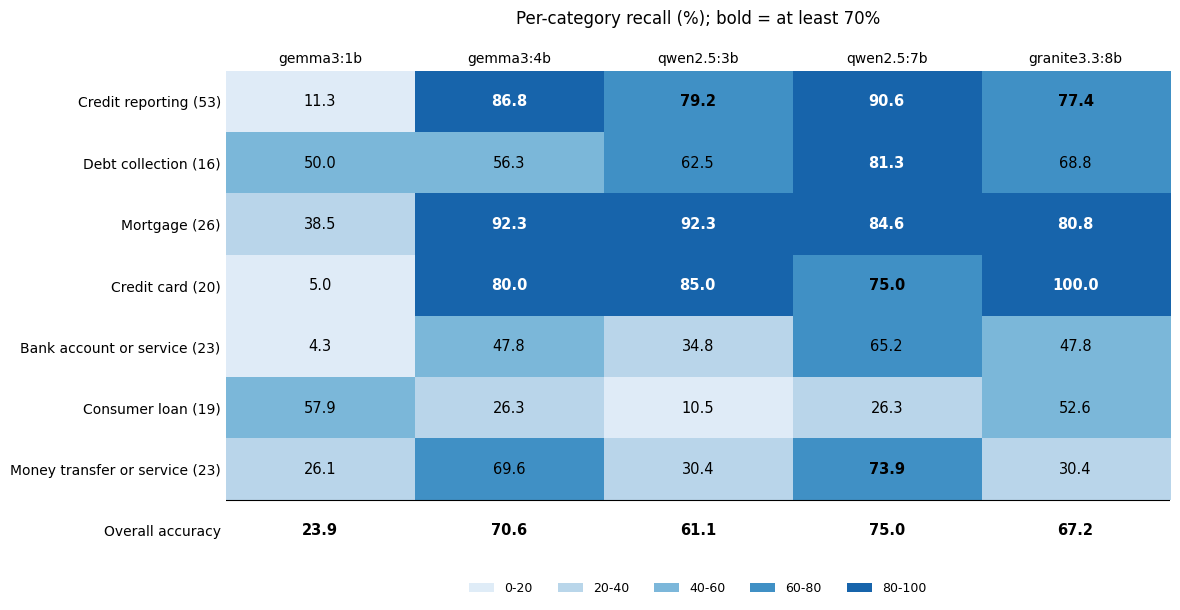

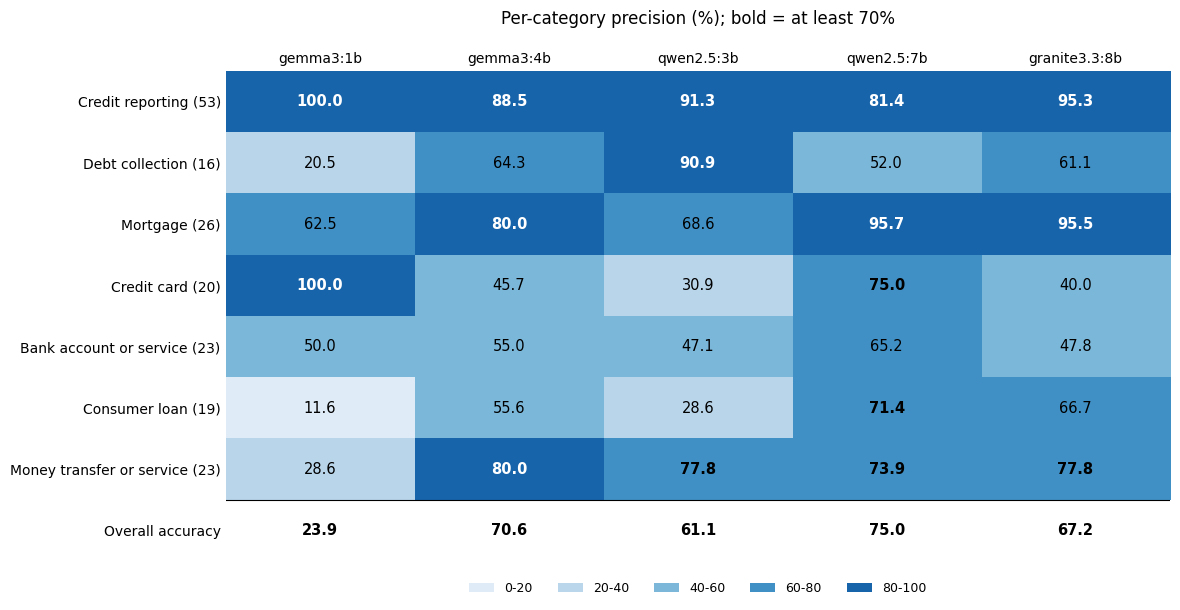

In [5]:
#HEATMAPS
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

FLOOR = 70


def metric_grid(cms, metric):
    """Rows = 7 categories + overall accuracy, columns = models."""
    models = list(cms)
    grid = np.full((len(CATEGORIES) + 1, len(models)), np.nan)
    for k, m in enumerate(models):
        v = cms[m][CATEGORIES + [UNMATCHED]].values
        diag = np.array([cms[m].loc[c, c] for c in CATEGORIES])

        base = v.sum(axis=1) if metric == 'recall' else v.sum(axis=0)[:len(CATEGORIES)]
        grid[:-1, k] = np.where(base > 0, 100 * diag / np.maximum(base, 1), np.nan)
        grid[-1, k] = 100 * diag.sum() / v.sum()
    return models, grid


def draw_heatmap(cms, metric):
    models, grid = metric_grid(cms, metric)
    cmap = ListedColormap(plt.cm.Blues(np.linspace(0.12, 0.80, 5)))
    cmap.set_bad('white')
    norm = BoundaryNorm([0, 20, 40, 60, 80, 100.0001], cmap.N)
    shown = np.ma.masked_invalid(grid.copy())
    shown[-1, :] = np.ma.masked                      # overall row stays unshaded

    n_per_cat = cms[models[0]].sum(axis=1)
    fig, ax = plt.subplots(figsize=(1.7 * len(models) + 3.4, 6.2))
    ax.imshow(shown, cmap=cmap, norm=norm, aspect='auto')
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                ax.text(j, i, 'n/a', ha='center', va='center', fontsize=10, color='#888888')
                continue
            is_cat = i < len(CATEGORIES)
            ax.text(j, i, f'{float(rhu(v)):.1f}', ha='center', va='center', fontsize=10.5,
                    fontweight='bold' if (v >= FLOOR or not is_cat) else 'normal',
                    color='white' if (is_cat and v >= 80) else 'black')
    ax.axhline(len(CATEGORIES) - 0.5, color='black', lw=0.8)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=10)
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(CATEGORIES) + 1))
    ax.set_yticklabels([f'{c} ({n})' for c, n in zip(CATEGORIES, n_per_cat)] + ['Overall accuracy'], fontsize=10)
    ax.tick_params(length=0)
    for side in ax.spines.values():
        side.set_visible(False)
    ax.set_title(f'Per-category {metric} (%); bold = at least {FLOOR}%', fontsize=12, pad=34)
    labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
    ax.legend(handles=[Patch(facecolor=cmap(k), label=l) for k, l in enumerate(labels)],
              loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f'heatmap_{metric}.png', dpi=200, bbox_inches='tight')   # directly in results/
    plt.show()


for metric in ('recall', 'precision'):
    draw_heatmap(cms, metric)

In [6]:
# output
for model in cms:
    print(model_dir(model) / 'confusion_matrix.png')
for p in sorted(RESULTS_DIR.glob('*.png')):
    print(p)

C:\Users\brand\ICT3113-A1-Team8\results\gemma3_1b\confusion_matrix.png
C:\Users\brand\ICT3113-A1-Team8\results\gemma3_4b\confusion_matrix.png
C:\Users\brand\ICT3113-A1-Team8\results\qwen2.5_3b\confusion_matrix.png
C:\Users\brand\ICT3113-A1-Team8\results\qwen2.5_7b\confusion_matrix.png
C:\Users\brand\ICT3113-A1-Team8\results\granite3.3_8b\confusion_matrix.png
C:\Users\brand\ICT3113-A1-Team8\results\confusion_matrices_all_models.png
C:\Users\brand\ICT3113-A1-Team8\results\heatmap_precision.png
C:\Users\brand\ICT3113-A1-Team8\results\heatmap_recall.png
